folder      : C:\Users\paraj\Documents\bayesian-die-swell-main\datas\infer-oldroyd-rom1\giesekus_lam_1_beta_0p5_alpha_0p01
points      : 247 (thin=1)
curve noise : 2.0% of disp, sigma 0.002621 (realized 0.002398)


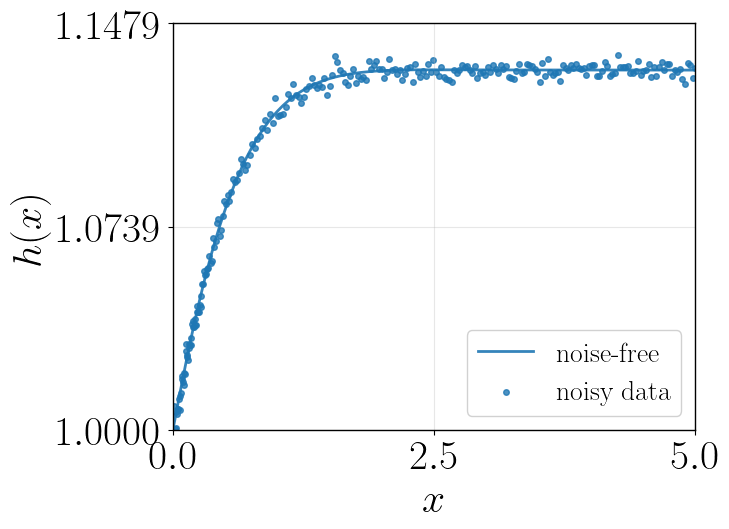

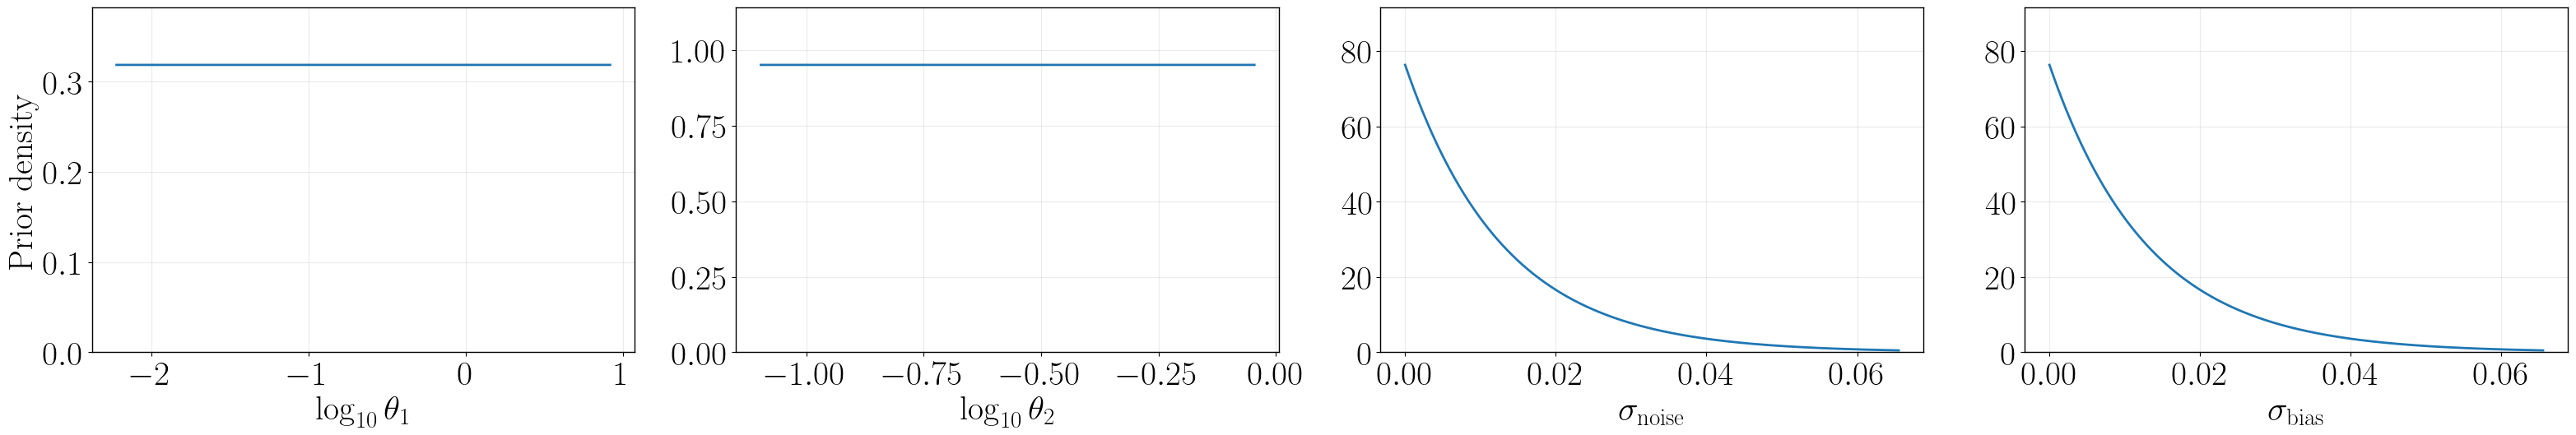

curve4_y GPR on (theta1, theta2), 120 curves: 0.686**2 * RBF(length_scale=[0.0614, 0.391])
parametrize bounds: theta1 (0.005999999999999998, 8.280000000000001), theta2 (0.08, 0.9), implied lambda (0.06, 9.0)
orthogonality constraint: no-bias best fit theta* = [0.39641 0.59424]
Initial walkers (first 10 of 10, physical space):
          theta1        theta2   sigma_noise    sigma_bias
          1.9041       0.47898      0.011608      0.014161
         0.18228       0.29192      0.014594      0.015149
        0.017924          0.73      0.013879     0.0099664
           1.493       0.14856      0.011064      0.017267
        0.070964       0.73803      0.013389      0.014606
          4.6639       0.17731     0.0078566      0.017849
         0.54384       0.49357      0.016716      0.016235
           0.437       0.14568      0.010572     0.0050902
         0.12086       0.12625      0.013481       0.01799
        0.062603       0.30664      0.012402     0.0099293


100%|██████████| 2000/2000 [00:15<00:00, 131.76it/s]


Walkers restarted after warm-up (first 10 of 10, physical space):
          theta1        theta2   sigma_noise    sigma_bias
          0.5777       0.34528     0.0023438    0.00060365
         0.54826       0.33773     0.0023314    0.00026893
         0.57341       0.35076     0.0023463     0.0005603
         0.57451        0.4145     0.0023381     0.0001243
         0.57856       0.34764     0.0023463    0.00033986
         0.57118       0.35589     0.0023531      0.000312
         0.56796       0.36589     0.0023394    0.00045048
         0.57915       0.39086     0.0023714    0.00024491
         0.56686       0.35192     0.0023411    0.00065383
         0.57212       0.35114     0.0023125    0.00052642


100%|██████████| 10000/10000 [01:18<00:00, 127.40it/s]


Parameter              Mean         Std      Rhat     95% CI Low    95% CI High
theta1           5.0992e-01  1.2747e-01     1.110     3.1124e-01     7.7158e-01
theta2           4.5212e-01  1.6148e-01     1.105     1.2077e-01     7.0437e-01
sigma_noise      2.4259e-03  1.0225e-04     1.010     2.2379e-03     2.6430e-03
sigma_bias       7.8311e-04  8.9755e-04     1.014     1.7353e-05     3.2143e-03
tau_xy = 0.401058 (R|dp/dx|/2 from pressure_drop.txt, dp/dx = -0.802116), gammadot_w = 0.4, eta0 = tau_xy / gammadot_w = 1.00264
E[N1] (oldroyd) = 0.163606 +/- 0.0408997  (95% CI [0.0998602, 0.247558], n=70000)
E[S_R] = 0.407936 +/- 0.10198  (95% CI [0.248992, 0.617262])  E[tau_w] = 0.401058


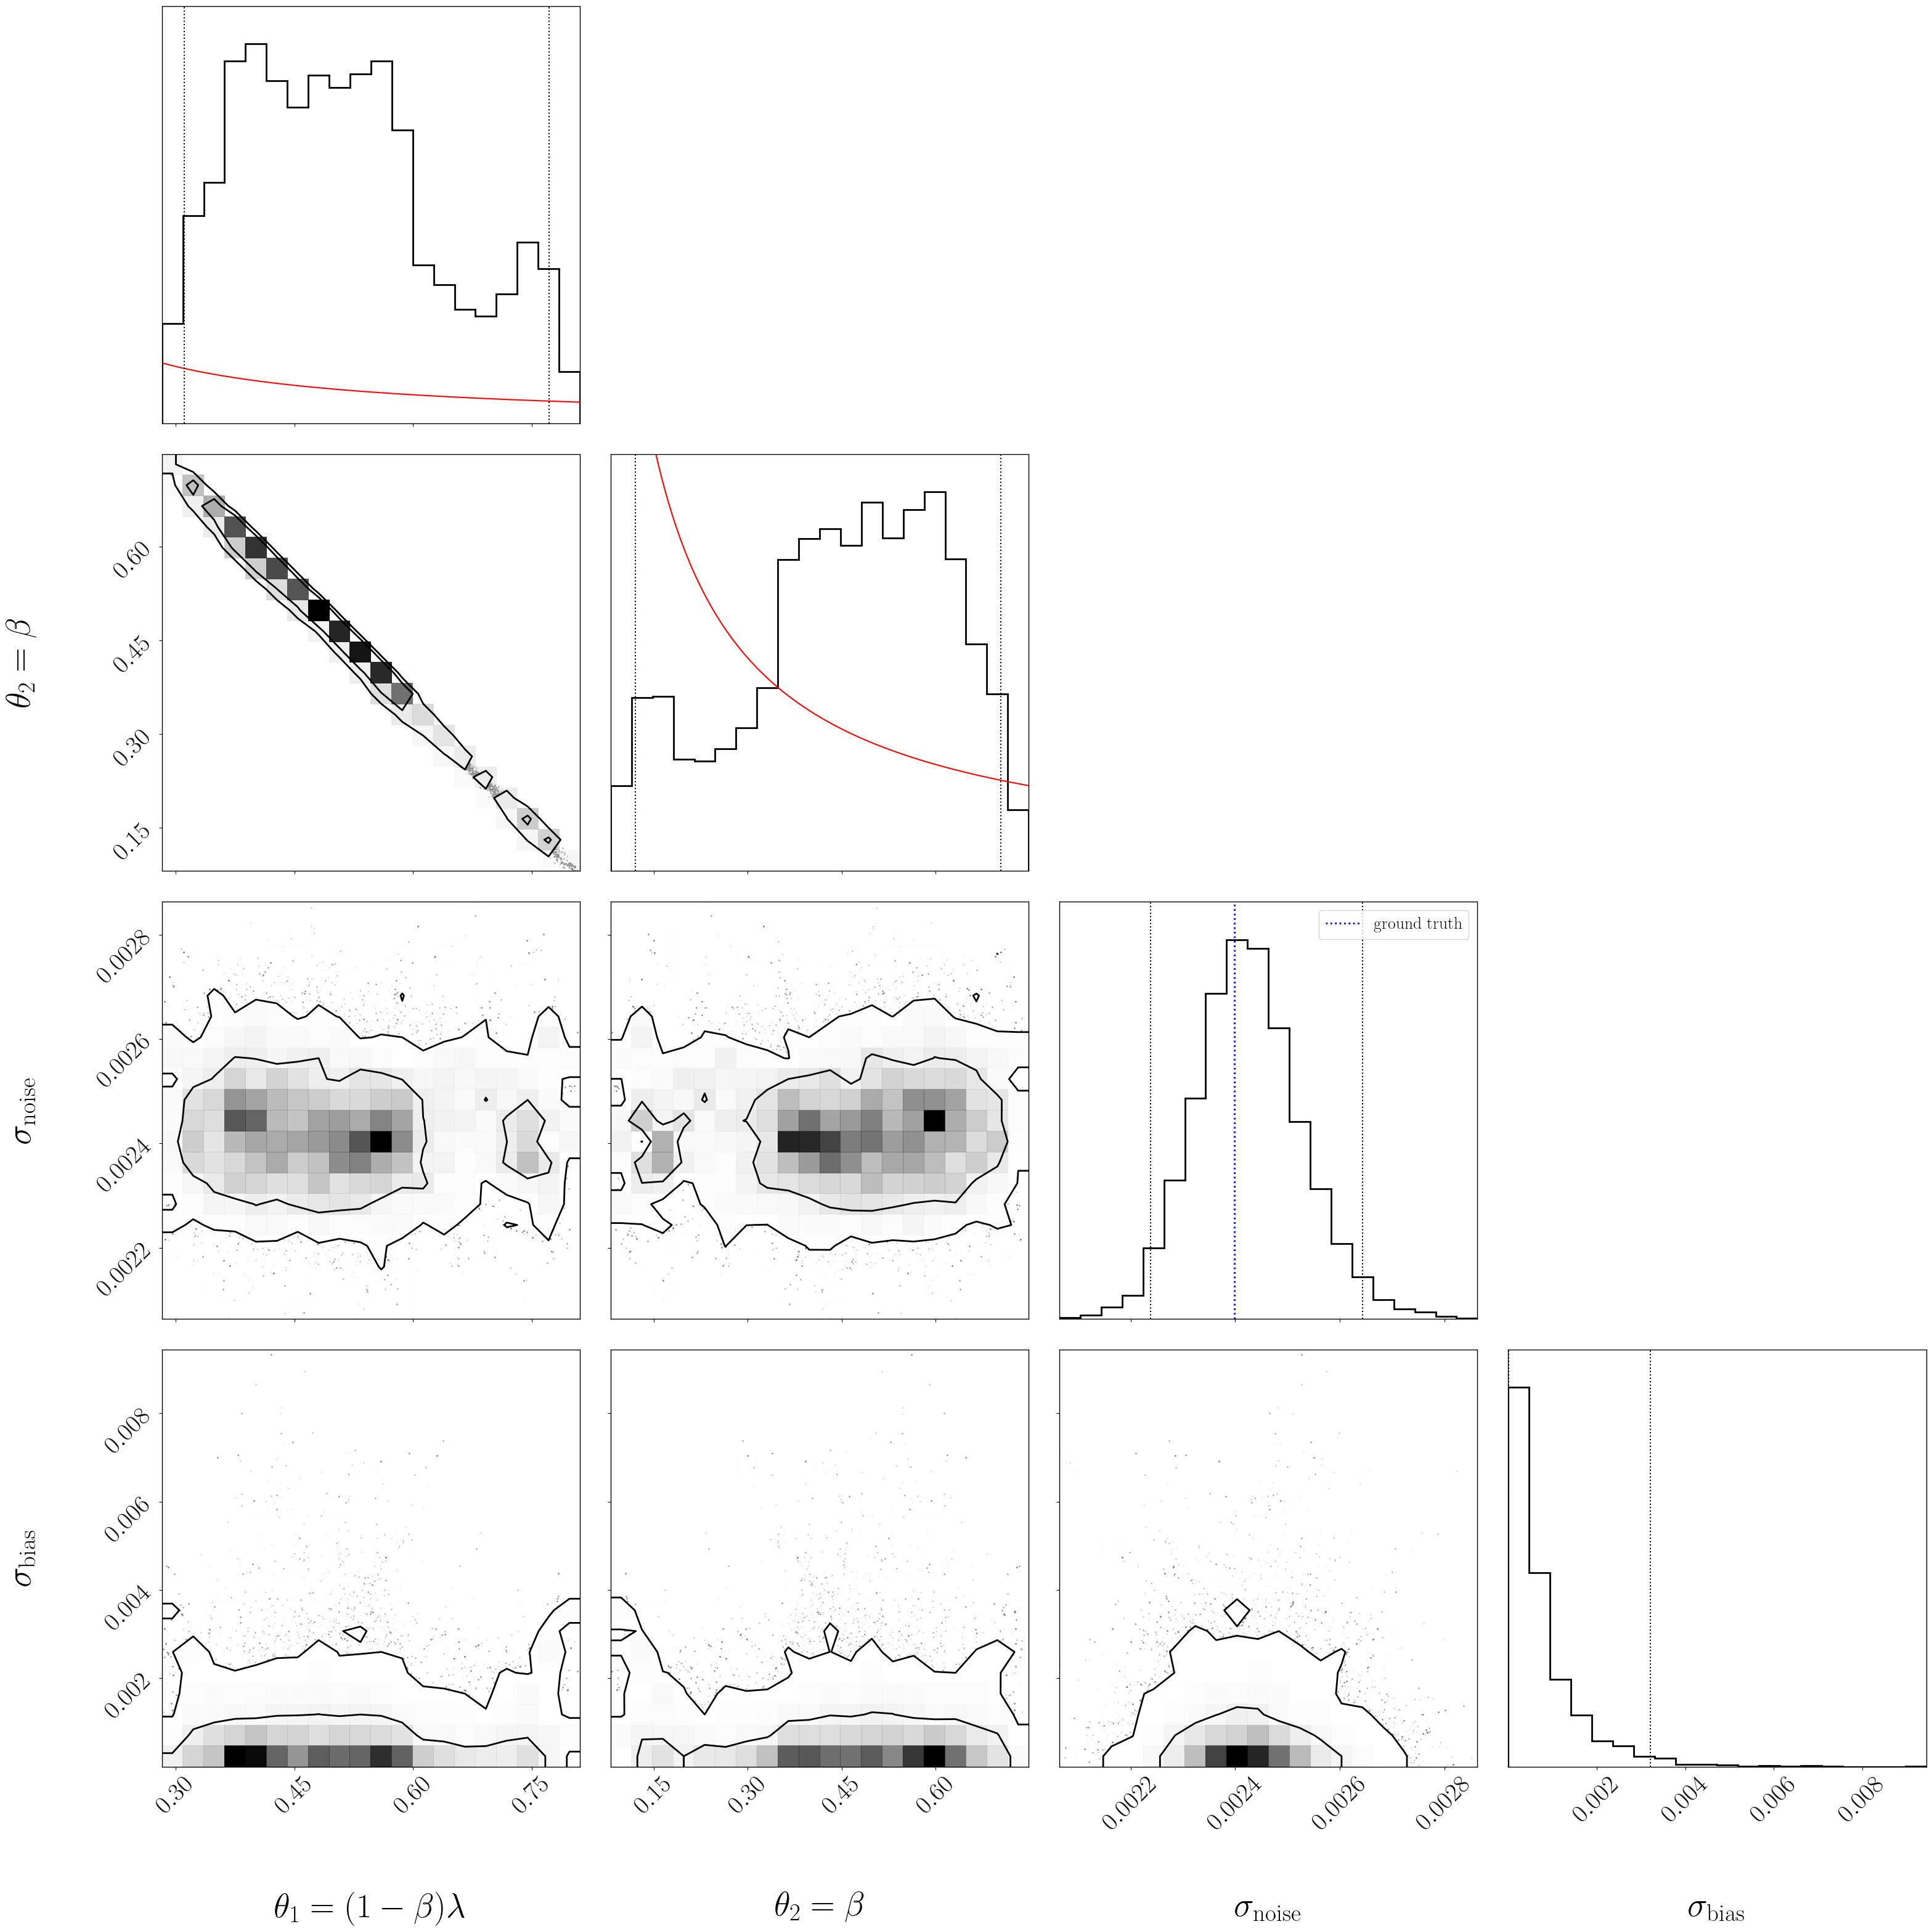

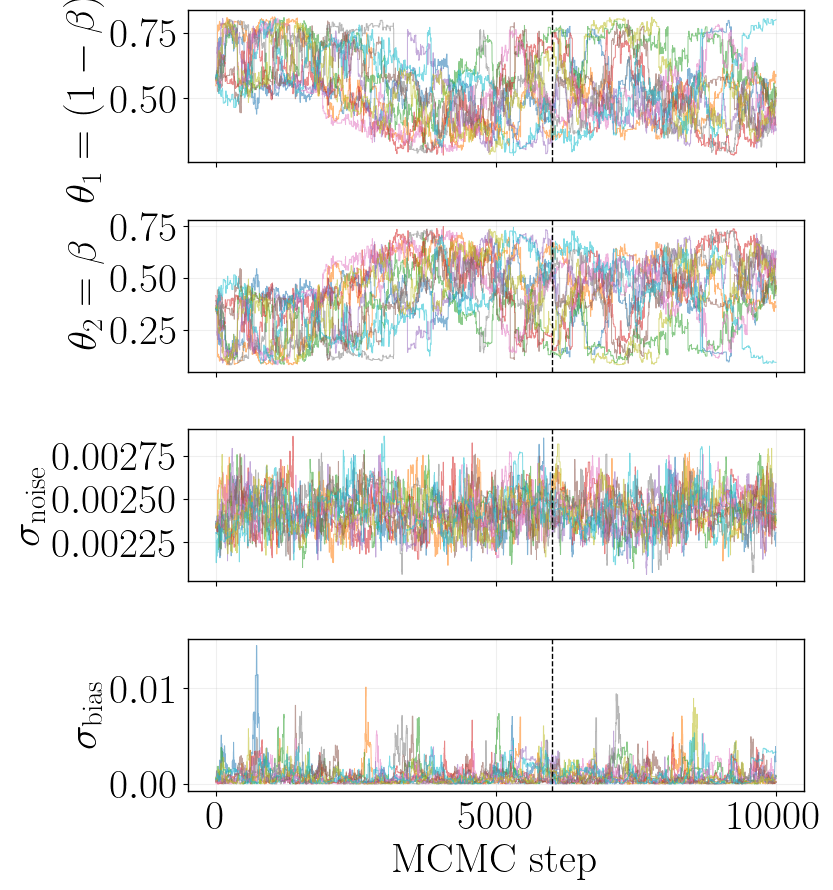

In [ ]:
import sys
import os
from pathlib import Path

CURRENT_DIR = os.getcwd()
FAXEN_ROOT = os.path.abspath(os.path.join(CURRENT_DIR, '..'))
sys.path.append(FAXEN_ROOT)
from packages import ROMCurve4BayesianInference

model = ROMCurve4BayesianInference(
    swell_root=Path(FAXEN_ROOT),
    model="oldroyd",
    parametrize = True,   
    train_data_rels=["datas/oldroyd-rom1"],    
    filenames_train=("curve4_y_all.txt",  "parameters.txt"),  
    lambda_bounds = (0.06, 9.0),
    beta_bounds = (0.08, 0.9),
    sigma_noise_percent=2.0,
    thin=1,
    sigma_bias=None,
    constrained_model_error=True,
    orthogonality_constraint=True,
    l_bias = 0.51)

model.load_data(filename="datas/infer-oldroyd-rom1/giesekus_lam_1_beta_0p5_alpha_0p01/curve4_y.txt")
model.plot_data()
model.plot_prior()
model.build_rom()
model.run_mcmc(nwalkers=10, nsteps=10000, warmup_fraction=0.2, burn_fraction=0.3)
model.compute_N1(U_avg = 0.1)
model.plot_corner_all()
model.plot_trace_all()
model.plot_posterior_predictive()